# Google Play Store Apps Analysis

## Introduction

The Google Play Store contains millions of Android applications across different categories such as Games, Education, Business, Finance, Health, Entertainment, and Lifestyle.

Understanding user preferences, app performance, ratings, reviews, installs, and pricing helps developers and businesses make better decisions.

In this project, we perform Exploratory Data Analysis (EDA) using Python to identify trends, discover patterns, clean the data, and generate meaningful business insights.

---

## Objectives

The objectives of this project are:

- Understand the structure of the dataset.
- Clean missing and inconsistent data.
- Convert data into appropriate formats.
- Analyze ratings, installs, reviews, prices, and app categories.
- Create meaningful visualizations.
- Answer business-related questions using Python.
- Provide recommendations based on the analysis.

## Step 1 : Select a real-world dataset


In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats



**Pandas Used for: <br>
Reading CSV,Cleaning data, Filtering, Creating new columns**


**NumPy used for: <br>
Mathematical calculations and Numerical operations**

**Matplotlib Creates <br>
Bar charts, Histograms, Pie charts, Line charts etc**

**Seaborn creates professional graphs<br>
Heatmaps, Boxplots, Violin plots, Countplox etc**



>**Data Preparation**

In [2]:
# Loading and Reading the csv file
a=pd.read_csv("/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv")
df=pd.DataFrame(a)


In [3]:
# Display the first five rows.
df.head()    

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
# Display the last five rows.
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [5]:
# Dataset shape i.e., rows and columns

df.shape

SyntaxError: invalid syntax (4006402208.py, line 1)

In [ ]:
# Display the column name
print(f'Column name:\n{df.columns}')

In [ ]:
# Information about the data, like DataType, memory usage, Number of rows and columns, non-null count etc.,

df.info()

## **Step 2 : Data Cleaning** 

>**Checking for the null values**

In [ ]:
# Counting the null values for each columns

df.isnull().sum()

**Here we can observe that column such as:<br>
Rating, Type, Content Rating, Current Ver, Android Ver have null values**

In [ ]:
# Filling the null values with the median of Rating value

r_median = df["Rating"].median()
df["Rating"] = df["Rating"].fillna(r_median)

In [ ]:
# Filling the null values on Rating column with the mode (most frequent value) T_
t_mode = df["Type"].mode()[0]

df["Type"] = df["Type"].fillna(t_mode)

In [ ]:
df["Current Ver"].mode()  #'Varies with device' value in the Current ver category repeats the most

In [ ]:
# Filling the null values with mode value 
df["Current Ver"] = df["Current Ver"].fillna(df["Current Ver"].mode()[0])

In [9]:
# Treat Android Version

df["Android Ver"] = df["Android Ver"].fillna(df["Android Ver"].mode()[0])

In [ ]:
#Treating Content Rating column

mode_content = df["Content Rating"].mode()[0]
df["Content Rating"] = df["Content Rating"].fillna(mode_content)

In [ ]:
df.isnull().sum()

>**Checking for the duplicated values**

In [ ]:
# Count for the duplicate rows

df.duplicated().sum()

In [ ]:
#Removing duplicate value

df.drop_duplicates(inplace=True)

In [ ]:
# Checking for the duplicates once again

df.duplicated().sum()   # 0 duplicates now

>**Checking for the Invalid values i.e., NaN values**

In [ ]:
df.isna().values.any()

In [ ]:
# Count NaN value per Column

df.isna().sum()

In [ ]:
# Checking null values in entire DataFrame

df.isna().sum().sum()     # Returns count of NaN values in entire dataframe

df.isna().any().any()     # Returns Boolean value if NaN value is present

In [ ]:
# Checks which column has NaN values 
df.isna().any()


In [ ]:
# Checks rows with NaN values

df[df.isna().any(axis=1)]

In [ ]:
# Drops row with atleast one NaN
df.dropna(inplace=True)  


In [ ]:
df.isna().sum()  # Treated NaN values  

>Chekcing for Rating greater than 5 (invalid)

In [ ]:
df['Rating'].max()

In [ ]:
df[df['Rating']>5]      # Used concept of boolean masking
                        # No such values found that is greater than 5

 > **Data Type conversion**

In [ ]:
# Here we could observe that Reviews, Size, Install and Price column are
# in object Dtype, whereas it must be of numeric Dtype


df.info()   

In [ ]:
# Conversion to Integer data type from Pandas Object using astype() function

df['Reviews']=df['Reviews'].astype(int)  

In [ ]:
# pd.to_numeric() coverts data to numeric types (floats or integers), with advanced error handling

df['Size']=pd.to_numeric(df['Size'])     

In [ ]:
 #errors="coerce" replaces invalid values with NaN.

df['Installs']=pd.to_numeric(df['Installs'], errors="coerce")

In [ ]:
df['Price']=pd.to_numeric(df['Price'])

In [ ]:
df['Size']=pd.to_numeric(df['Size'])

**Clean the Installs Column- removing the commas and '+'**

In [ ]:
df['Installs']=df['Installs'].str.replace(',','', regex=False).str.replace('+','',regex=False)

In [ ]:
df['Installs']

**Replacing '$' in Price column**

In [ ]:
df['Price']=df['Price'].str.replace("$","",regex=False)      # regex=False  replaces only the actual '$' symbol 

In [ ]:
df[df['Price'].str.contains('\$')]    # checking result

In [ ]:
# checks unique value in Price column

df['Price'].unique()


**Statistical Data Overview**

In [ ]:
df.describe()   # for numerial columns

In [ ]:
df.describe(include='object')      # For non-numerical columns

In [10]:
df.describe(include='all')           # For all columns-numerical as well as non-numerical

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10841
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2454
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Step 3 : Visualization**

1. Category Distribution


In [ ]:

count = df['Category'].value_counts()
plt.figure(figsize=(10,5))

count.head(10).plot(kind='bar', color= '#91008D')

plt.title("Top 10 App Categories", fontsize=15, fontweight='bold')

plt.xlabel("Category", fontsize=12)

plt.ylabel("Number of Apps", fontsize=12)

plt.xticks(rotation=45)

plt.show()

**Most of the apps related to the category - family, Games, and Tools dominated the Goggle play store**

>Grouping average Rating by Category

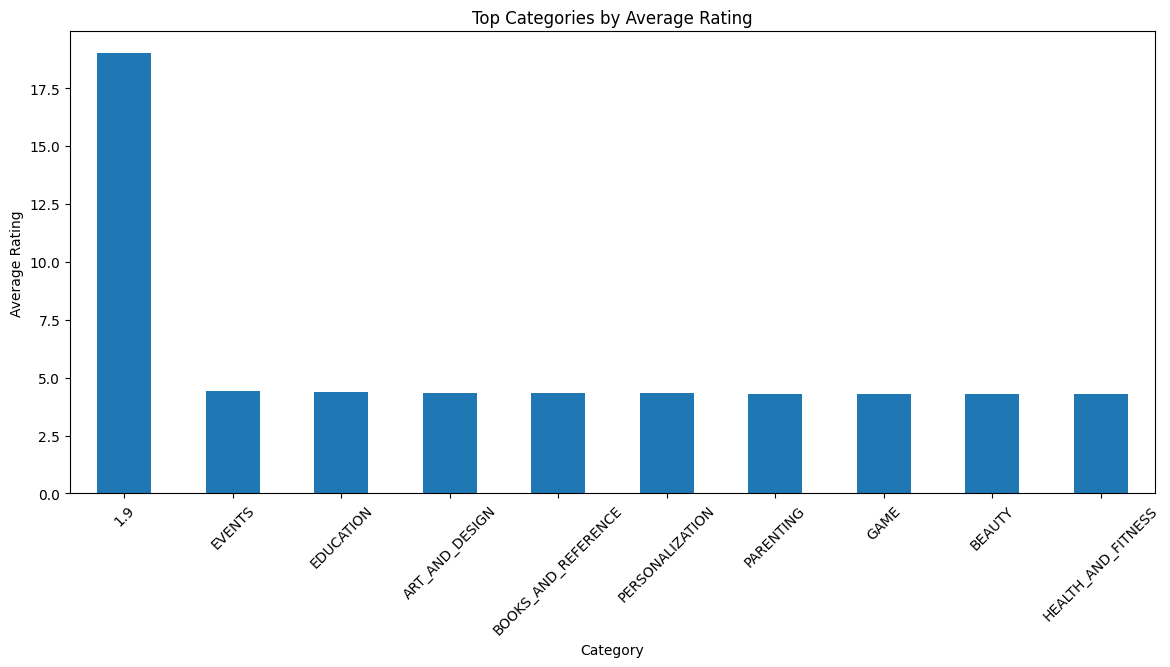

In [18]:
avg_rating = df.groupby("Category")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(14,6))

avg_rating.head(10).plot(kind='bar')

plt.title("Top Categories by Average Rating")

plt.xlabel("Category")
plt.xticks(rotation=45)

plt.ylabel("Average Rating")

plt.show()

> Distribution of Free vs Paid apps using a pie chart

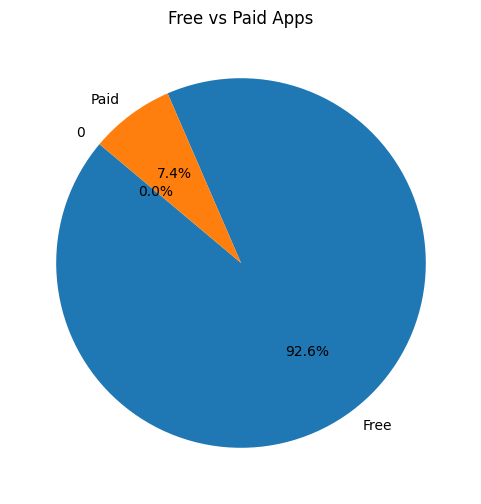

In [16]:
type_count = df['Type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(type_count,
        labels=type_count.index,
        autopct="%1.1f%%",
        startangle=140)

plt.title("Free vs Paid Apps")

plt.show()

> App size vs Rating using scatter plot

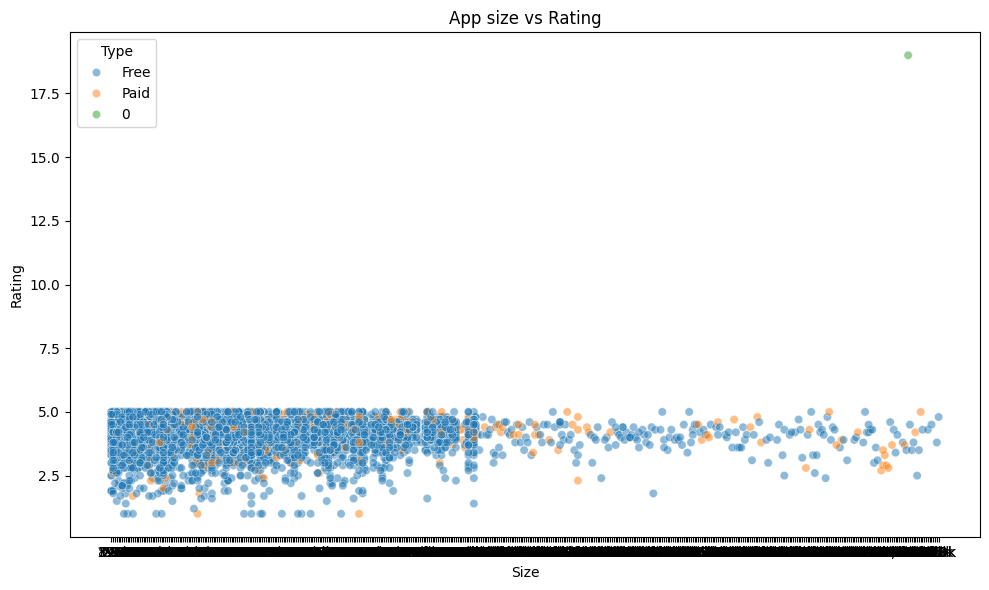

In [13]:

plt.figure(figsize=(10,6))
sns.scatterplot(x='Size', y='Rating', data=df, hue='Type', alpha=0.5)
plt.title('App size vs Rating')

plt.tight_layout()
plt.show()

> Relation between content rating and Rating columns using boxplot and detecting outliers is any

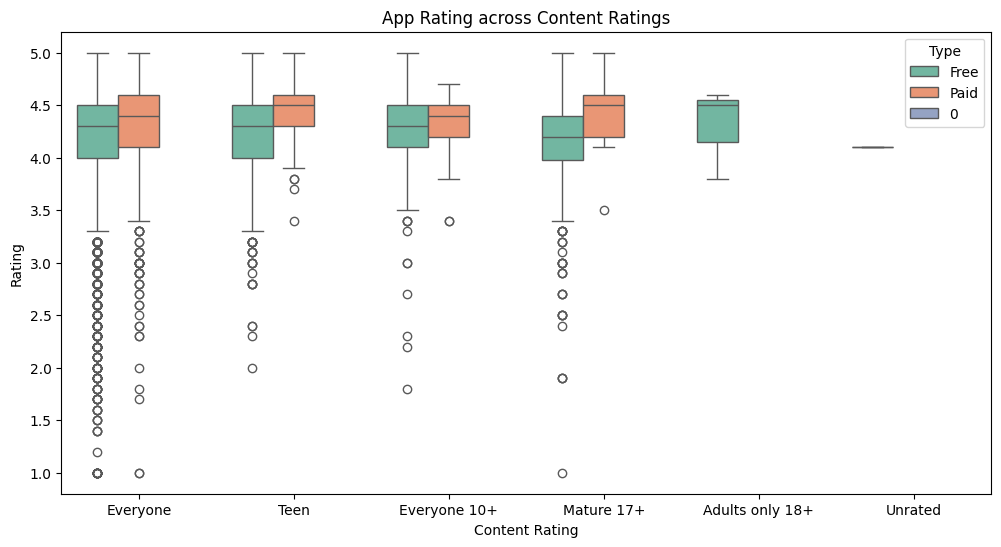

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Content Rating',y='Rating',data=df, hue='Type', palette='Set2')
plt.title('App Rating across Content Ratings')
plt.show()

> Count of Apps per Category


/tmp/ipykernel_58/4189608148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=df, palette='viridis')


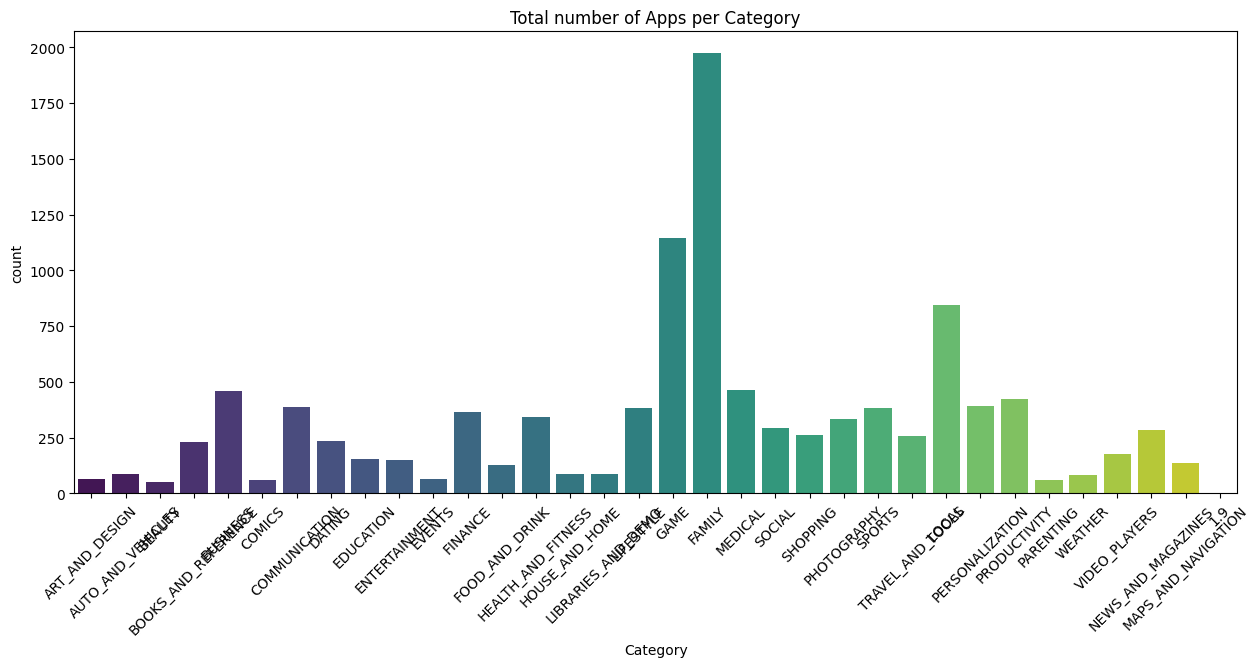

In [14]:
plt.figure(figsize=(15,6))
sns.countplot(x='Category', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Total number of Apps per Category')
plt.show()

>Distribution of App Rating


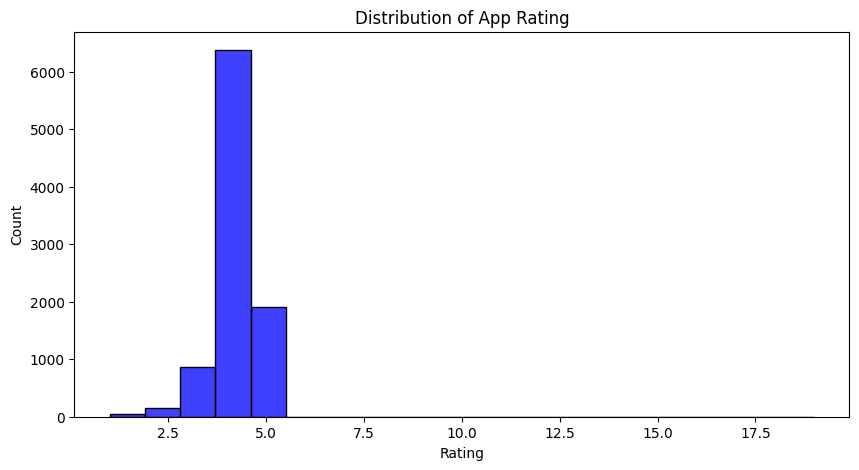

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(df['Rating'].dropna(),bins=20, color='blue')
plt.title('Distribution of App Rating')
plt.xlabel('Rating')
plt.show()

## ***Business Questions***

**1] Which top 5 application categories received the highest average user rating?**

In [16]:
# groupby('Category') group all applications according to their category 

rating_info=df.groupby("Category")["Rating"].mean().sort_values(ascending=False)        # sort the values from highest to lowest
rating_info.head(5)


Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.389032
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.346067
Name: Rating, dtype: float64

**2] Top 10 categories that have the highest number of installs?** 

In [21]:
install_info=df.groupby("Category")["Installs"].sum().sort_values(ascending=False)
install_info.head(10)

Category
1.9                                                                 Free
PRODUCTIVITY           500,000,000+10,000,000+100,000,000+10,000,000+...
BEAUTY                 500,000+1,000,000+100,000+500,000+1,000,000+50...
FAMILY                 50,000,000+10,000,000+100,000,000+1,000,000+5,...
WEATHER                50,000,000+1,000,000+50,000,000+10,000+10,000,...
PERSONALIZATION        50,000,000+1,000,000+100,000,000+5,000,000+100...
LIBRARIES_AND_DEMO     50,000+10,000+100,000+1,000+100,000+10,000+100...
LIFESTYLE              5,000,000+10,000,000+100,000+10,000,000+5,000,...
BOOKS_AND_REFERENCE    100,000,000+50,000+100,000+10,000,000+100,000,...
MAPS_AND_NAVIGATION    100,000,000+5,000,000+10,000,000+10,000,000+5,...
Name: Installs, dtype: object

**3] Are the paid applications rated higher than free apps?**

In [28]:
type_info= df.groupby("Type")["Rating"].mean().sort_values(ascending=False)
type_info.head()

Type
0       19.000000
Paid     4.266615
Free     4.186203
Name: Rating, dtype: float64

**4] Relationship between app reviews and installs?**

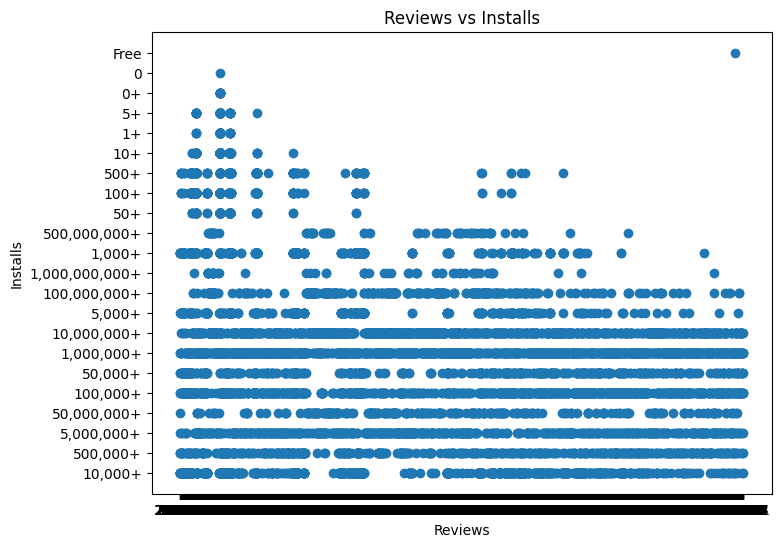

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(df['Reviews'],df['Installs'])
plt.title('Reviews vs Installs')
plt.xlabel("Reviews")
plt.ylabel("Installs")
plt.show()

**5] Which content rating is most common?**

In [37]:
com= df["Rating"].value_counts().sort_values(ascending=False)
com.head(10)

Rating
4.4    1109
4.3    1076
4.5    1038
4.2     952
4.6     823
4.1     708
4.0     568
4.7     499
3.9     386
3.8     303
Name: count, dtype: int64

**6] Which genre has the highest rating?**

In [47]:
rating_info=df.groupby("Genres")["Rating"].mean().sort_values(ascending=False)
rating_info.head(10)

Genres
February 11, 2018              19.000000
Board;Pretend Play              4.800000
Comics;Creativity               4.800000
Health & Fitness;Education      4.700000
Puzzle;Education                4.600000
Strategy;Action & Adventure     4.600000
Adventure;Brain Games           4.600000
Entertainment;Creativity        4.533333
Music;Music & Video             4.533333
Racing;Pretend Play             4.500000
Name: Rating, dtype: float64

### Summary 

This project performed Exploratory Data Analysis (EDA) on the Google Play Store dataset to understand the factors influencing app popularity, user ratings, installs, and overall app performance. The dataset was cleaned and preprocessed by handling missing values, removing duplicates, converting data types, and preparing the data for analysis.

Using Python, Pandas, Matplotlib, and Seaborn, various business questions and visualizations were created to analyze app categories, ratings, reviews, installs, prices, content ratings, and genres. The analysis identified trends in user preferences, high-performing app categories, and the relationship between app popularity and user satisfaction.

Overall, this project demonstrates how data analytics can help app developers, product managers, and businesses make data-driven decisions to improve app quality, optimize pricing strategies, enhance user engagement, and increase app downloads and revenue.